<a href="https://colab.research.google.com/github/Umair-khitab/Aviator-Game-Prediction-App/blob/main/LAB003_AS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  LAB 03 — Exploratory Data Analysis (EDA)
> **Complete EDA** — All Sections + Bonus challng

| Section | Topic |
|---|---|
| 1 | Summary Statistics |
| 2 | Visualizing Distributions |
| 3 | Handling Missing Values |
| 4 | Handling Outliers |
| 5 | Feature Engineering & Selection |
|  | Bonus: Automated EDA Report Generator |


##  Install & Import Libraries


In [1]:
# Install any missing packages (scikit-learn is pre-installed in Colab)
!pip install -q scikit-learn scipy seaborn matplotlib pandas numpy


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import skew, kurtosis, zscore
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print(' All libraries imported successfully!')

 All libraries imported successfully!


## Generate Dataset
> A synthetic **housing dataset** with missing values, outliers, and redundant features — fully self-contained, no CSV needed.


In [4]:
def generate_messy_dataset(n=300, seed=42):
    """
    Generates a realistic messy housing dataset with:
      - ~8% missing values per numeric column
      - Outliers injected in price & sqft
      - A redundant feature (price_per_sqft)
      - One categorical column (neighborhood)
    """
    rng = np.random.default_rng(seed)

    age        = rng.integers(1, 60, n).astype(float)
    bedrooms   = rng.integers(1, 6, n).astype(float)
    bathrooms  = rng.integers(1, 4, n).astype(float)
    sqft       = np.clip(rng.normal(1500, 400, n), 400, 5000)
    price      = 50_000 + sqft * 120 + bedrooms * 15_000 + rng.normal(0, 20_000, n)
    price_per_sqft = price / sqft   # redundant (highly correlated with price)
    garage     = rng.integers(0, 3, n).astype(float)
    neighborhood = rng.choice(['Urban', 'Suburban', 'Rural'], n)

    df = pd.DataFrame({
        'age': age, 'bedrooms': bedrooms, 'bathrooms': bathrooms,
        'sqft': sqft, 'price': price, 'price_per_sqft': price_per_sqft,
        'garage': garage, 'neighborhood': neighborhood
    })

    # Inject outliers
    df.loc[rng.choice(n, 8, replace=False), 'price'] *= 6
    df.loc[rng.choice(n, 5, replace=False), 'sqft']  *= 4

    # Inject missing values (~8% per column)
    for col in ['age', 'bedrooms', 'bathrooms', 'sqft', 'price', 'garage']:
        df.loc[rng.choice(n, int(n * 0.08), replace=False), col] = np.nan
    df.loc[rng.choice(n, 15, replace=False), 'neighborhood'] = np.nan

    return df

df_raw = generate_messy_dataset(n=300)
print(f'Dataset created: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head()


Dataset created: 300 rows × 8 columns


,age,bedrooms,bathrooms,sqft,price,price_per_sqft,garage,neighborhood
0,6.0,2.0,2.0,1689.878835,283950.946865,168.030359,1.0,Urban
1,46.0,5.0,3.0,1447.565340,309682.617144,213.933429,1.0,Urban
2,39.0,1.0,3.0,767.637670,153363.100541,199.785793,1.0,Suburban
3,26.0,5.0,1.0,1871.318797,355121.130124,189.770514,2.0,Suburban
4,26.0,3.0,3.0,1257.999715,249122.347483,198.030528,1.0,Suburban


---
##  Section 1 — Summary Statistics


In [5]:
# 1.1 Dataset structure
print('=== df.info() ===')
df_raw.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             276 non-null    float64
 1   bedrooms        276 non-null    float64
 2   bathrooms       276 non-null    float64
 3   sqft            276 non-null    float64
 4   price           276 non-null    float64
 5   price_per_sqft  300 non-null    float64
 6   garage          276 non-null    float64
 7   neighborhood    285 non-null    object 
dtypes: float64(7), object(1)
memory usage: 18.9+ KB


In [6]:
# 1.2 Missing values & duplicates
print('=== Missing values per column ===')
print(df_raw.isnull().sum())
print(f'\nTotal missing cells : {df_raw.isnull().sum().sum()}')
print(f'Missing % of dataset: {df_raw.isnull().mean().mean()*100:.1f}%')
print(f'\nDuplicated rows     : {df_raw.duplicated().sum()}')


=== Missing values per column ===
age               24
bedrooms          24
bathrooms         24
sqft              24
price             24
price_per_sqft     0
garage            24
neighborhood      15
dtype: int64

Total missing cells : 159
Missing % of dataset: 6.6%

Duplicated rows     : 0


In [8]:
# 1.3 Descriptive statistics
print('=== df.describe() ===')
df_raw.describe()

=== df.describe() ===


,age,bedrooms,bathrooms,sqft,price,price_per_sqft,garage
count,276.000000,276.000000,276.000000,276.000000,2.760000e+02,300.000000,276.000000
mean,29.355072,2.931159,2.068841,1537.580475,3.105261e+05,192.294460,0.949275
std,15.835427,1.491420,0.834902,761.582253,2.263410e+05,37.710891,0.811933
min,2.000000,1.000000,1.000000,474.102263,1.290890e+05,132.485757,0.000000
25%,17.000000,2.000000,1.000000,1169.460655,2.414574e+05,168.179322,0.000000
50%,28.000000,3.000000,2.000000,1445.371851,2.768504e+05,185.338702,1.000000
75%,43.000000,4.000000,3.000000,1732.959045,3.100589e+05,208.327658,2.000000
max,59.000000,5.000000,3.000000,7804.830172,1.747720e+06,384.366556,2.000000


In [10]:
# 1.4 Skewness & Kurtosis
num_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns

stats_df = pd.DataFrame({
    'Skewness' : df_raw[num_cols].skew(),
    'Kurtosis' : df_raw[num_cols].kurtosis()
})
print('=== Skewness & Kurtosis ===')
print(stats_df)
print('\n  Skew > |1| = highly skewed | Kurtosis > 3 = heavy-tailed')


=== Skewness & Kurtosis ===
                Skewness   Kurtosis
age             0.020121  -1.099614
bedrooms        0.085480  -1.406768
bathrooms      -0.130149  -1.554950
sqft            5.058940  35.402569
price           5.238189  27.800936
price_per_sqft  1.736791   4.900109
garage          0.093230  -1.476877

  Skew > |1| = highly skewed | Kurtosis > 3 = heavy-tailed


---
##  Section 2 — Visualizing Distributions


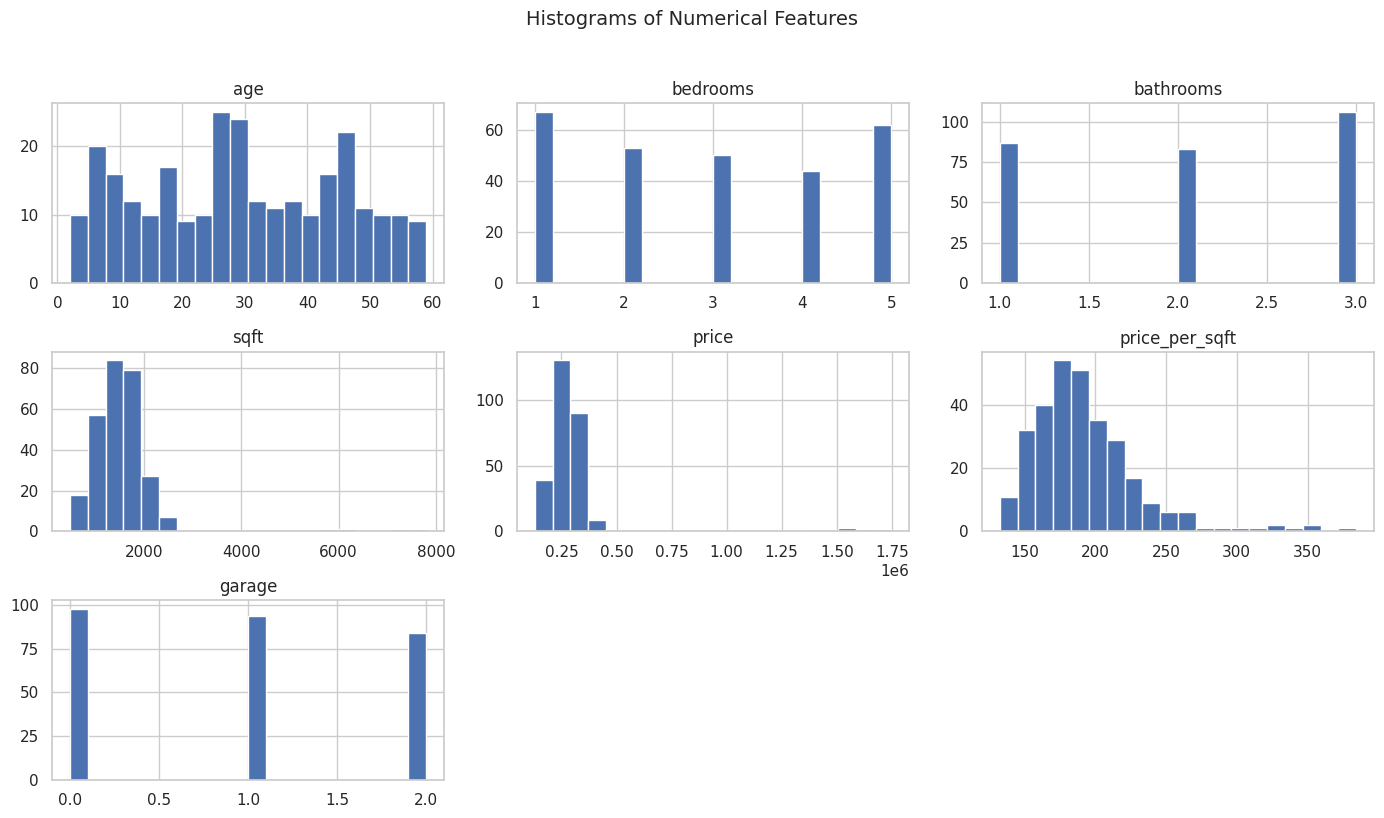

In [11]:
# 2.1 Histograms
df_raw[num_cols].hist(figsize=(14, 8), bins=20, color='#4C72B0', edgecolor='white')
plt.suptitle('Histograms of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

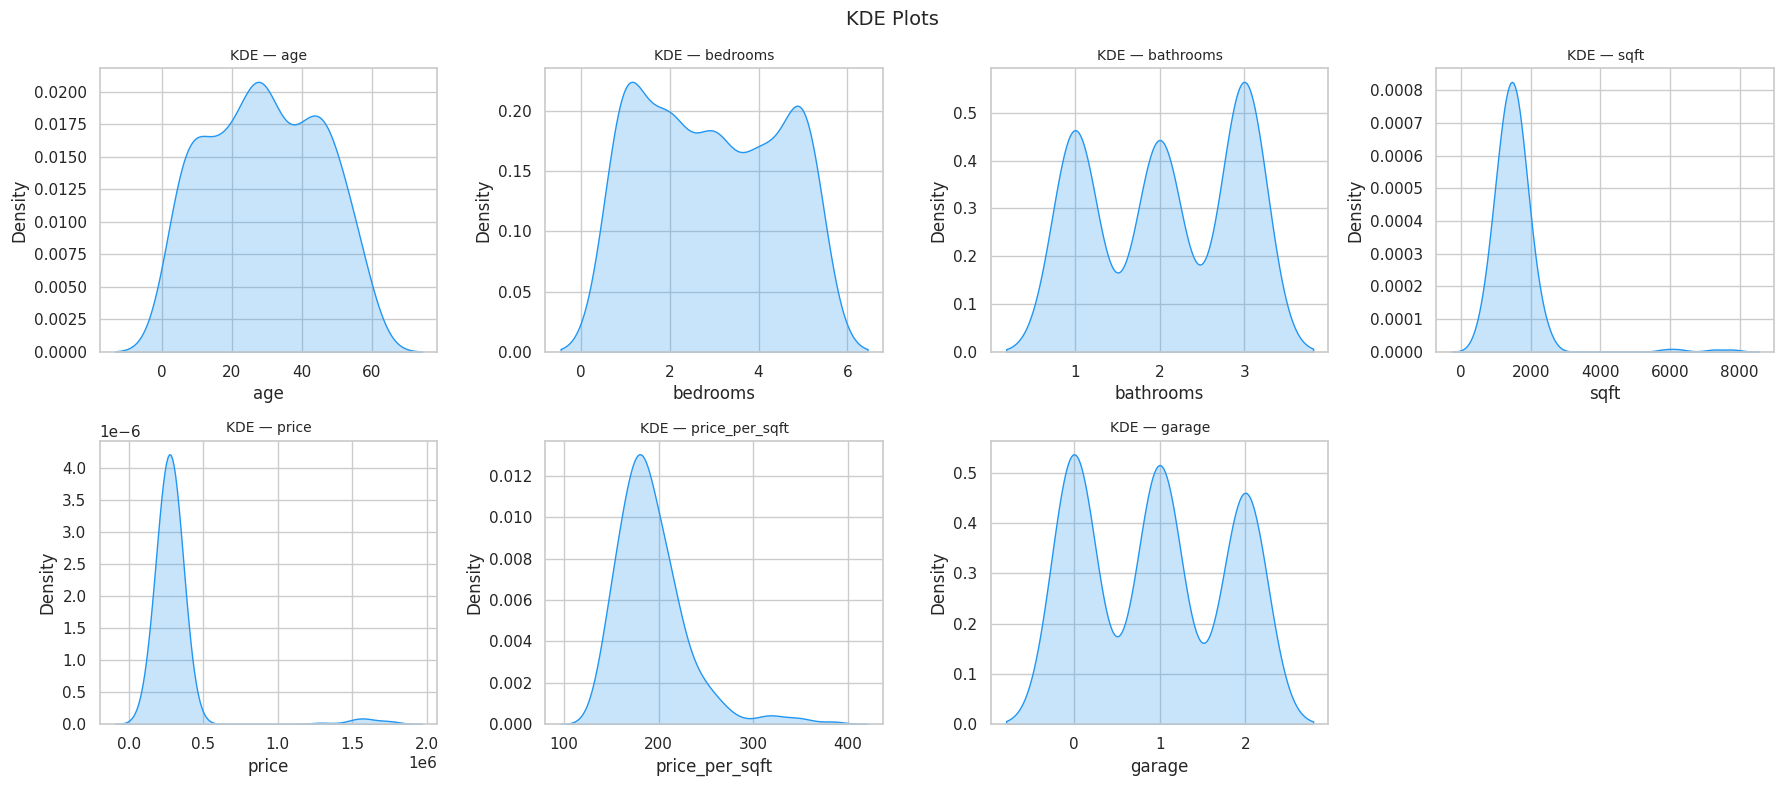

In [12]:
# 2.2 KDE Plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(df_raw[col].dropna(), fill=True, ax=axes[i], color='#2196F3')
    axes[i].set_title(f'KDE — {col}', fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('KDE Plots', fontsize=14)
plt.tight_layout()
plt.show()

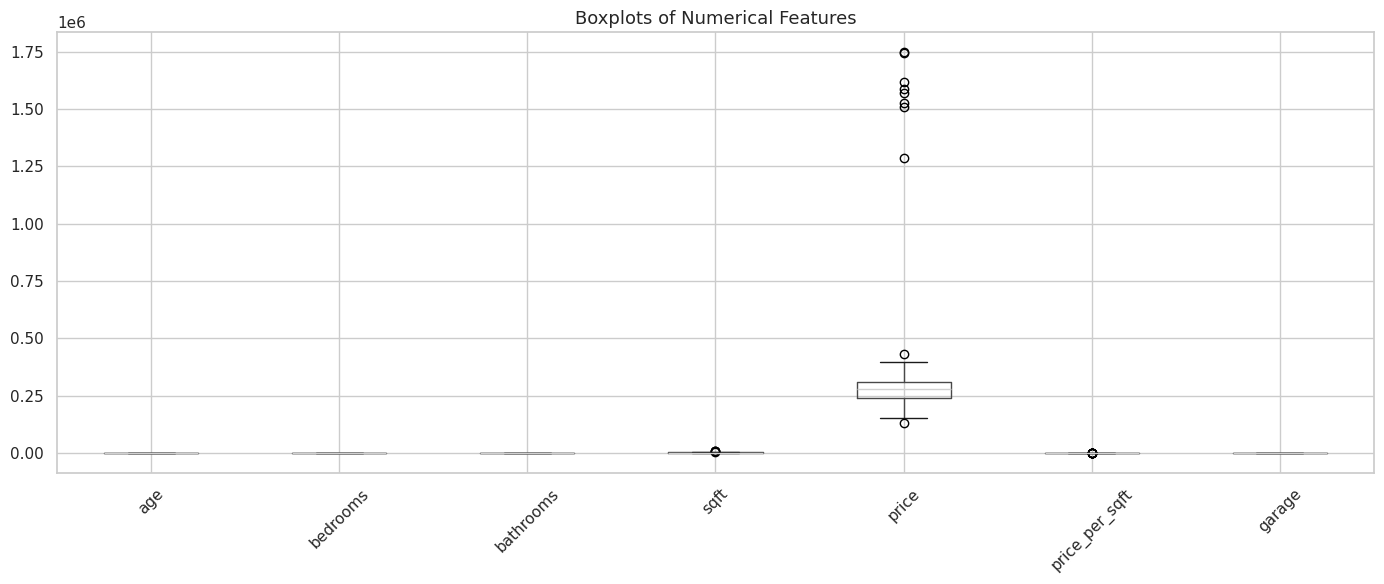

In [13]:
# 2.3 Boxplots
plt.figure(figsize=(14, 6))
df_raw[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

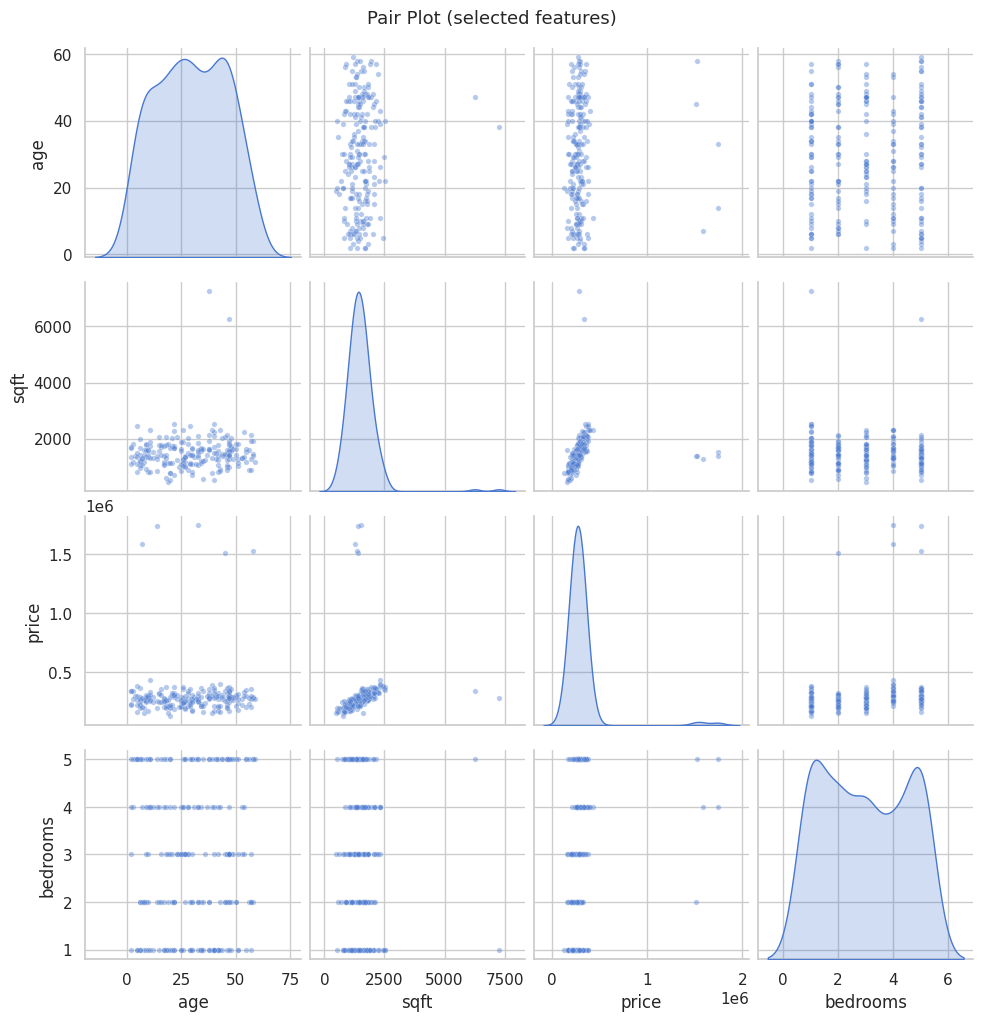

In [14]:
# 2.4 Pair Plot (uses a sample to stay fast in Colab)
pair_cols = ['age', 'sqft', 'price', 'bedrooms']
sns.pairplot(df_raw[pair_cols].dropna(), diag_kind='kde',
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot (selected features)', y=1.02, fontsize=13)
plt.show()


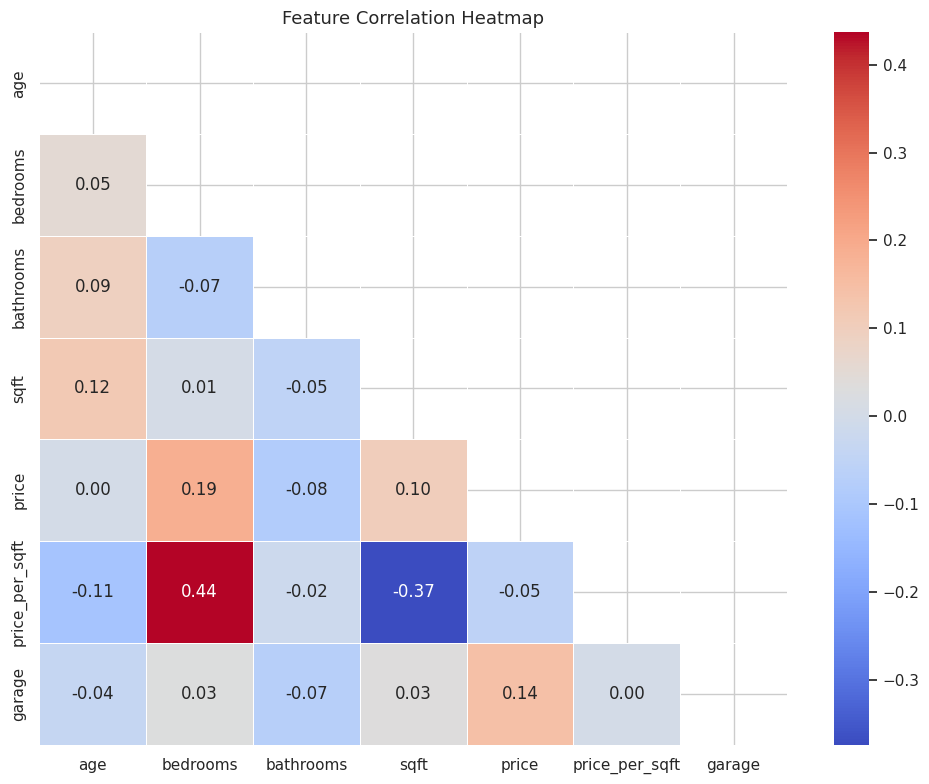

In [15]:
# 2.5 Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 3 — Handling Missing Values


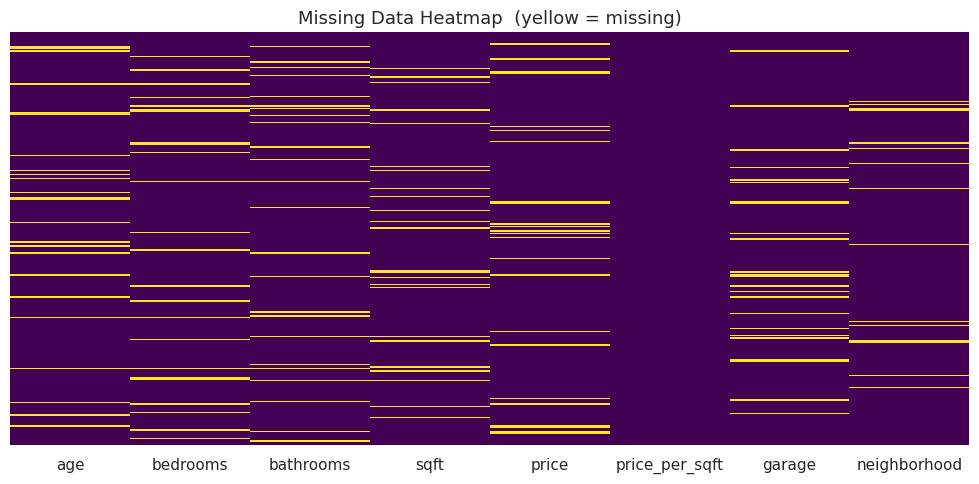

In [16]:
# 3.1 Visualise missing data
plt.figure(figsize=(10, 5))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap  (yellow = missing)', fontsize=13)
plt.tight_layout()
plt.show()


In [17]:
# 3.2 Imputation
df_imputed = df_raw.copy()

# Numerical: KNN Imputation (most robust)
num_cols_list = df_raw.select_dtypes(include=['float64', 'int64']).columns.tolist()
imputer = KNNImputer(n_neighbors=5)
df_imputed[num_cols_list] = imputer.fit_transform(df_imputed[num_cols_list])

# Categorical: mode
cat_cols = df_raw.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

print('Missing values BEFORE imputation:')
print(df_raw.isnull().sum())
print('\nMissing values AFTER KNN imputation:')
print(df_imputed.isnull().sum())


Missing values BEFORE imputation:
age               24
bedrooms          24
bathrooms         24
sqft              24
price             24
price_per_sqft     0
garage            24
neighborhood      15
dtype: int64

Missing values AFTER KNN imputation:
age               0
bedrooms          0
bathrooms         0
sqft              0
price             0
price_per_sqft    0
garage            0
neighborhood      0
dtype: int64


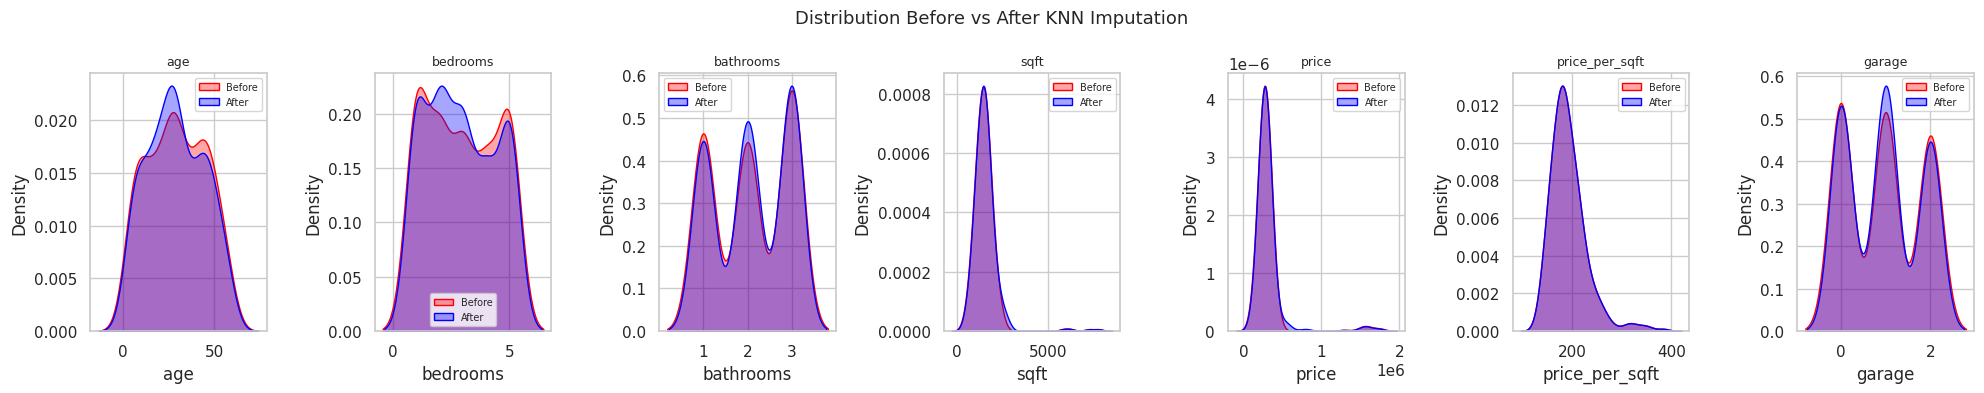

In [18]:
# 3.3 Distribution before vs after imputation
fig, axes = plt.subplots(1, len(num_cols_list), figsize=(20, 4))
for ax, col in zip(axes, num_cols_list):
    sns.kdeplot(df_raw[col].dropna(),   ax=ax, label='Before', color='red',  fill=True, alpha=0.35)
    sns.kdeplot(df_imputed[col],        ax=ax, label='After',  color='blue', fill=True, alpha=0.35)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Distribution Before vs After KNN Imputation', fontsize=13)
plt.tight_layout()
plt.show()

---
##  Section 4 — Handling Outliers


In [19]:
# 4.1 Detect with IQR
Q1 = df_imputed[num_cols_list].quantile(0.25)
Q3 = df_imputed[num_cols_list].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = ((df_imputed[num_cols_list] < (Q1 - 1.5*IQR)) |
                (df_imputed[num_cols_list] > (Q3 + 1.5*IQR))).sum()

print('Outliers detected per column (IQR method):')
print(iqr_outliers)

Outliers detected per column (IQR method):
age                0
bedrooms           0
bathrooms          0
sqft               9
price             19
price_per_sqft    11
garage             0
dtype: int64


In [20]:
# 4.2 Detect with Z-score
z_scores = np.abs(zscore(df_imputed[num_cols_list]))
z_outliers = (z_scores > 3).sum(axis=0)
print('Outliers per column (Z-score |z|>3):')
print(pd.Series(z_outliers, index=num_cols_list))


Outliers per column (Z-score |z|>3):
age               0
bedrooms          0
bathrooms         0
sqft              4
price             8
price_per_sqft    8
garage            0
dtype: int64


In [21]:
# 4.3 Treat outliers — Automated function (Winsorization / cap)
def cap_outliers(df, column, lo_pct=0.01, hi_pct=0.99):
    lo = df[column].quantile(lo_pct)
    hi = df[column].quantile(hi_pct)
    df[column] = np.clip(df[column], lo, hi)
    return df

def auto_treat_outliers(df, method='cap'):
    """method: 'cap' | 'remove' | 'log'"""
    df_out = df.copy()
    cols   = df_out.select_dtypes(include=['float64', 'int64']).columns

    if method == 'cap':
        for col in cols:
            df_out = cap_outliers(df_out, col)

    elif method == 'remove':
        z = np.abs(zscore(df_out[cols]))
        df_out = df_out[(z <= 3).all(axis=1)]

    elif method == 'log':
        for col in cols:
            if (df_out[col] > 0).all():
                df_out[col] = np.log1p(df_out[col])
    return df_out

df_capped = auto_treat_outliers(df_imputed, method='cap')

print('Price — BEFORE capping:')
print(df_imputed['price'].describe())
print('\nPrice — AFTER capping:')
print(df_capped['price'].describe())


Price — BEFORE capping:
count    3.000000e+02
mean     3.168089e+05
std      2.237726e+05
min      1.290890e+05
25%      2.443568e+05
50%      2.779099e+05
75%      3.157113e+05
max      1.747720e+06
Name: price, dtype: float64

Price — AFTER capping:
count    3.000000e+02
mean     3.157185e+05
std      2.164884e+05
min      1.537428e+05
25%      2.443568e+05
50%      2.779099e+05
75%      3.157113e+05
max      1.586312e+06
Name: price, dtype: float64


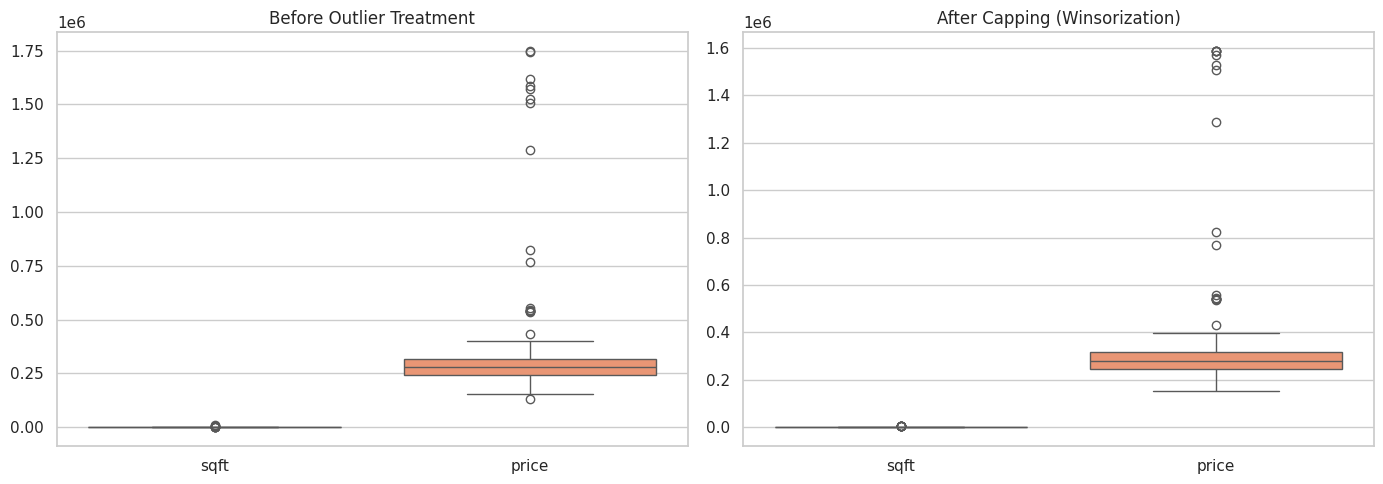

In [22]:
# 4.4 Visual comparison before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_imputed[['sqft', 'price']], ax=axes[0], palette='Set2')
axes[0].set_title('Before Outlier Treatment')
sns.boxplot(data=df_capped[['sqft', 'price']], ax=axes[1], palette='Set2')
axes[1].set_title('After Capping (Winsorization)')
plt.tight_layout()
plt.show()

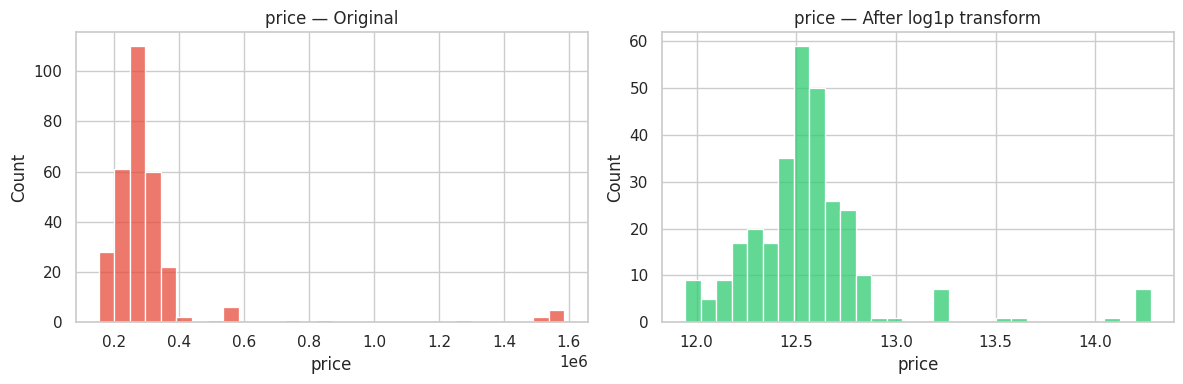

In [23]:
# Log transformation example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_capped['price'], bins=30, ax=axes[0], color='#e74c3c')
axes[0].set_title('price — Original')
sns.histplot(np.log1p(df_capped['price']), bins=30, ax=axes[1], color='#2ecc71')
axes[1].set_title('price — After log1p transform')
plt.tight_layout()
plt.show()

---
##  Section 5 — Feature Engineering & Selection


In [24]:
df_fe = df_capped.copy()

# New features
df_fe['total_rooms'] = df_fe['bedrooms'] + df_fe['bathrooms']
df_fe['age_group']   = pd.cut(df_fe['age'],
                               bins=[0, 10, 25, 45, 100],
                               labels=['New', 'Moderate', 'Old', 'Very Old'])
df_fe['price_log']   = np.log1p(df_fe['price'])

print(' New features created: total_rooms, age_group, price_log')

# Remove highly correlated / redundant features
num_fe = df_fe.select_dtypes(include=['float64', 'int64']).columns
corr_abs = df_fe[num_fe].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.92)]
print(f'  Highly correlated features to drop (corr > 0.92): {to_drop}')
df_fe.drop(columns=to_drop, errors='ignore', inplace=True)

print(f'\n Final columns: {df_fe.columns.tolist()}')
print(f' Final shape  : {df_fe.shape}')
df_fe.head()


 New features created: total_rooms, age_group, price_log
  Highly correlated features to drop (corr > 0.92): ['price_log']

 Final columns: ['age', 'bedrooms', 'bathrooms', 'sqft', 'price', 'price_per_sqft', 'garage', 'neighborhood', 'total_rooms', 'age_group']
 Final shape  : (300, 10)


,age,bedrooms,bathrooms,sqft,price,price_per_sqft,garage,neighborhood,total_rooms,age_group
0,6.0,2.0,2.0,1689.878835,283950.946865,168.030359,1.0,Urban,4.0,New
1,46.0,5.0,3.0,1447.565340,309682.617144,213.933429,1.0,Urban,8.0,Very Old
2,39.0,1.0,3.0,767.637670,153742.787015,199.785793,1.0,Suburban,4.0,Old
3,26.0,5.0,1.0,1871.318797,355121.130124,189.770514,2.0,Suburban,6.0,Old
4,26.0,3.0,3.0,1257.999715,249122.347483,198.030528,1.0,Suburban,6.0,Old


In [25]:
# Justification
print("""
╔══════════════════════════════════════════════════════════════╗
║            JUSTIFICATION OF CHOICES                         ║
╠══════════════════════════════════════════════════════════════╣
║ Missing values  → KNN Imputation                            ║
║   Why: Preserves correlations between features better than  ║
║   mean/median imputation, especially for correlated data.   ║
║                                                              ║
║ Outlier method  → Winsorization (capping)                   ║
║   Why: Retains all rows (no data loss). Better than removal  ║
║   when outliers are errors but dataset is small.             ║
║                                                              ║
║ Dropped feature → price_per_sqft (& price_log after adding) ║
║   Why: price_per_sqft = price/sqft → near-perfect           ║
║   correlation (>0.92) → redundant for ML models.            ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║            JUSTIFICATION OF CHOICES                         ║
╠══════════════════════════════════════════════════════════════╣
║ Missing values  → KNN Imputation                            ║
║   Why: Preserves correlations between features better than  ║
║   mean/median imputation, especially for correlated data.   ║
║                                                              ║
║ Outlier method  → Winsorization (capping)                   ║
║   Why: Retains all rows (no data loss). Better than removal  ║
║   when outliers are errors but dataset is small.             ║
║                                                              ║
║ Dropped feature → price_per_sqft (& price_log after adding) ║
║   Why: price_per_sqft = price/sqft → near-perfect           ║
║   correlation (>0.92) → redundant for ML models.            ║
╚══════════════════════════════════════════════════════════════╝



---
##  BONUS — Automated EDA Report Generator


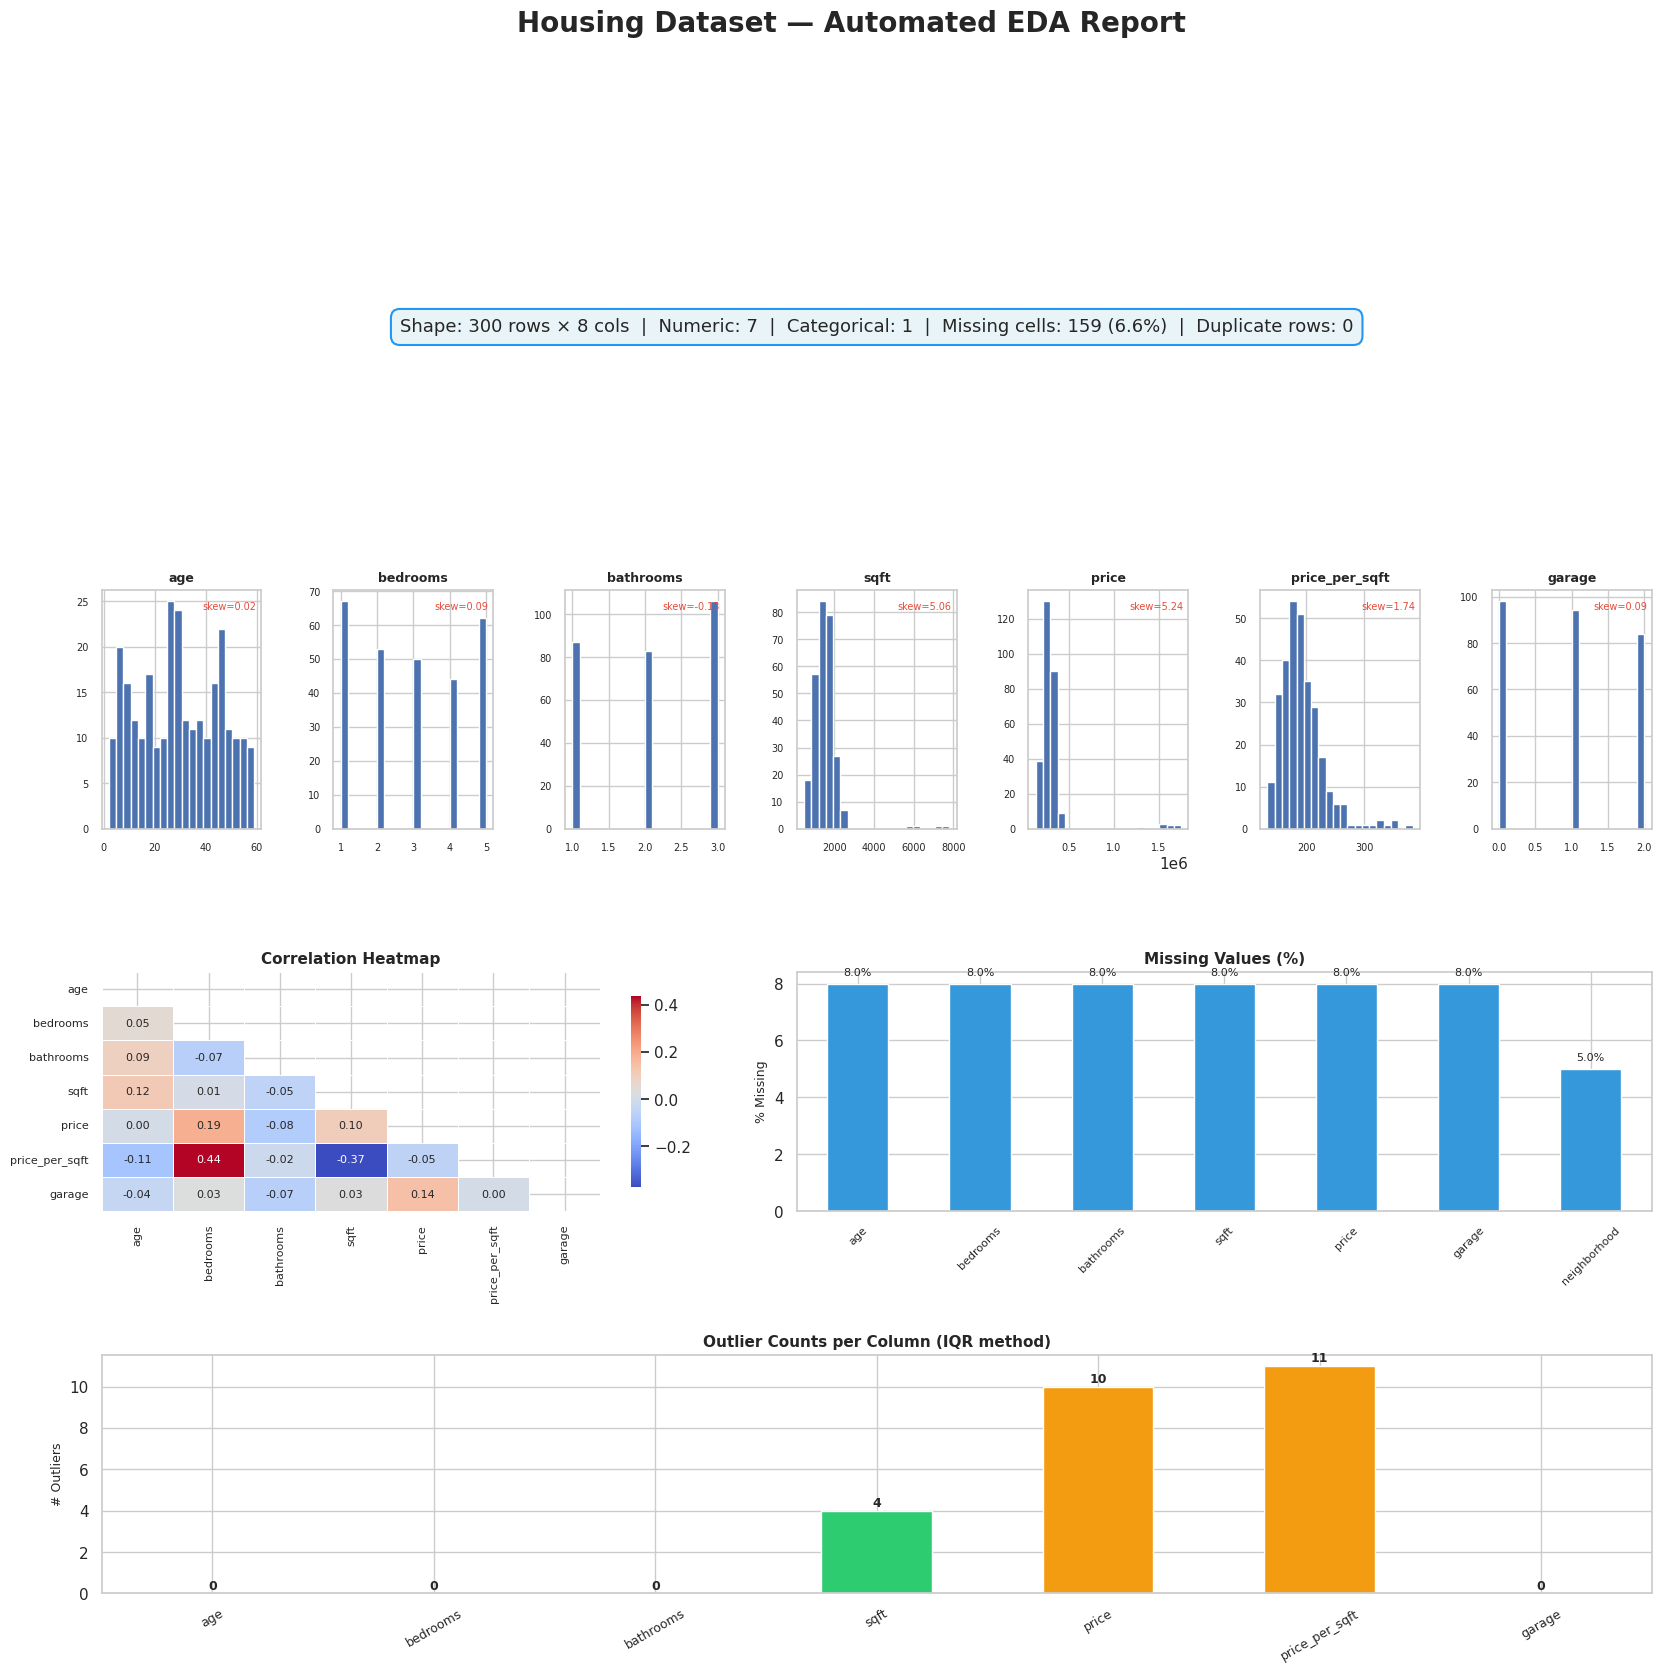


┌─────────── EDA SUMMARY ───────────┐
│ Rows        : 300                   │
│ Columns     : 8                     │
│ Missing     : 159 cells (6.6%)       │
│ Duplicates  : 0                     │
│ Total outliers (IQR): 25           │
│ Most skewed : price                 │
└───────────────────────────────────┘


In [26]:
def generate_eda_report(df, title='EDA Report'):
    """
    One-call EDA report function.
    Generates a 4-panel figure:
      Panel 1 — Dataset overview (text)
      Panel 2 — Histograms with skew labels
      Panel 3 — Correlation heatmap + Missing values bar
      Panel 4 — Outlier counts (IQR)
    Also prints a text summary to the console.
    """
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    n_num    = len(num_cols)
    n_cols   = max(n_num, 4)

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(title, fontsize=20, fontweight='bold', y=0.99)
    gs  = gridspec.GridSpec(4, n_cols, figure=fig, hspace=0.6, wspace=0.45)

    # ── Row 0: Overview text ─────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, :])
    ax0.axis('off')
    txt = (f"Shape: {df.shape[0]} rows × {df.shape[1]} cols  |  "
           f"Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}  |  "
           f"Missing cells: {df.isnull().sum().sum()} "
           f"({df.isnull().mean().mean()*100:.1f}%)  |  "
           f"Duplicate rows: {df.duplicated().sum()}")
    ax0.text(0.5, 0.5, txt, transform=ax0.transAxes,
             fontsize=13, va='center', ha='center',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4f8',
                       edgecolor='#2196F3', linewidth=1.5))

    # ── Row 1: Histograms ────────────────────────────────────────
    for i, col in enumerate(num_cols[:n_cols]):
        ax = fig.add_subplot(gs[1, i])
        ax.hist(df[col].dropna(), bins=20, color='#4C72B0', edgecolor='white')
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        sk = df[col].skew()
        ax.text(0.97, 0.95, f'skew={sk:.2f}', transform=ax.transAxes,
                fontsize=7, ha='right', va='top', color='#e74c3c')

    # ── Row 2: Heatmap (left) + Missing bar (right) ──────────────
    half = n_cols // 2
    ax_corr = fig.add_subplot(gs[2, :half])
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
                ax=ax_corr, linewidths=0.4, annot_kws={'size': 8},
                cbar_kws={'shrink': 0.8})
    ax_corr.set_title('Correlation Heatmap', fontsize=11, fontweight='bold')
    ax_corr.tick_params(labelsize=8)

    ax_miss = fig.add_subplot(gs[2, half:])
    miss = df.isnull().mean() * 100
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss):
        colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 10 else '#3498db'
                  for v in miss.values]
        miss.plot(kind='bar', ax=ax_miss, color=colors, edgecolor='white')
        ax_miss.set_title('Missing Values (%)', fontsize=11, fontweight='bold')
        ax_miss.set_ylabel('% Missing', fontsize=9)
        ax_miss.tick_params(axis='x', rotation=45, labelsize=8)
        for bar, val in zip(ax_miss.patches, miss):
            ax_miss.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.3, f'{val:.1f}%',
                         ha='center', fontsize=8)
    else:
        ax_miss.text(0.5, 0.5, 'No missing values ✔',
                     transform=ax_miss.transAxes, ha='center', va='center',
                     fontsize=14, color='green')
        ax_miss.axis('off')

    # ── Row 3: Outlier bar chart ──────────────────────────────────
    ax_out = fig.add_subplot(gs[3, :])
    Q1 = df[num_cols].quantile(0.25)
    Q3 = df[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    oc = ((df[num_cols] < (Q1 - 1.5*IQR)) |
          (df[num_cols] > (Q3 + 1.5*IQR))).sum()
    colors3 = ['#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#2ecc71'
               for v in oc.values]
    oc.plot(kind='bar', ax=ax_out, color=colors3, edgecolor='white')
    ax_out.set_title('Outlier Counts per Column (IQR method)',
                     fontsize=11, fontweight='bold')
    ax_out.set_ylabel('# Outliers', fontsize=9)
    ax_out.tick_params(axis='x', rotation=30, labelsize=9)
    for bar, val in zip(ax_out.patches, oc):
        ax_out.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2, str(int(val)),
                    ha='center', fontsize=9, fontweight='bold')

    plt.show()

    # Text summary
    print('\n┌─────────── EDA SUMMARY ───────────┐')
    print(f'│ Rows        : {df.shape[0]:<22}│')
    print(f'│ Columns     : {df.shape[1]:<22}│')
    print(f'│ Missing     : {df.isnull().sum().sum()} cells ({df.isnull().mean().mean()*100:.1f}%)       │')
    print(f'│ Duplicates  : {df.duplicated().sum():<22}│')
    print(f'│ Total outliers (IQR): {oc.sum():<13}│')
    print(f'│ Most skewed : {df[num_cols].skew().abs().idxmax():<22}│')
    print('└───────────────────────────────────┘')


# Run on the raw dataset
generate_eda_report(df_raw, title='Housing Dataset — Automated EDA Report')


---
##  Final Clean Dataset

In [27]:
print('=== Final cleaned dataset ===')
print(df_fe.head(10))
print(f'\nShape: {df_fe.shape}')
print(f'Missing values: {df_fe.isnull().sum().sum()}')
print('\n🎉 Dataset is clean and ready for Machine Learning!')


=== Final cleaned dataset ===
    age  bedrooms  bathrooms         sqft          price  price_per_sqft  \
0   6.0       2.0        2.0  1689.878835  283950.946865      168.030359   
1  46.0       5.0        3.0  1447.565340  309682.617144      213.933429   
2  39.0       1.0        3.0   767.637670  153742.787015      199.785793   
3  26.0       5.0        1.0  1871.318797  355121.130124      189.770514   
4  26.0       3.0        3.0  1257.999715  249122.347483      198.030528   
5  51.0       1.0        2.0  1286.439905  234928.136340      182.618819   
6   6.0       2.0        1.0  1072.099035  224792.049897      209.674706   
7  42.0       3.0        2.0  1238.286689  211196.962831      170.555789   
8  12.0       2.0        3.0  1671.156176  283995.414397      140.976273   
9   6.0       1.0        3.0  1424.302264  255951.179588      179.702852   

   garage neighborhood  total_rooms age_group  
0     1.0        Urban          4.0       New  
1     1.0        Urban          8.0  

In [29]:
#  save to CSV
df_fe.to_csv('housing_cleaned.csv', index=False)
print('✅ Saved as housing_cleaned.csv')


✅ Saved as housing_cleaned.csv
